# **Importing & Loading the Data**

In [ ]:
import pandas as pd

df = pd.read_excel('/content/Deliquency_prediction dataset.xlsx')
display(df.head())

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0025,55,41646.0,847.0,0.212567,5,0,28018.0,0.233027,retired,8,Standard,Los Angeles,On-time,Missed,Missed,Missed,Late,Late
1,CUST0198,61,59238.0,847.0,0.549147,5,1,22835.0,0.375727,Unemployed,16,Standard,New York,On-time,Missed,Missed,On-time,On-time,On-time
2,CUST0254,50,98042.0,847.0,0.568326,5,1,90739.0,0.305468,employed,0,Student,Houston,On-time,Missed,Late,Missed,Missed,On-time
3,CUST0498,54,152326.0,847.0,0.676950,0,0,44449.0,0.104839,Employed,16,Student,Phoenix,On-time,Late,Late,On-time,Late,Missed
4,CUST0470,62,75566.0,845.0,0.576488,4,0,82482.0,0.419492,employed,4,Standard,Houston,Late,Late,Late,Missed,Late,Missed


## **Exploratory Data Analysis**

#### Numnber of rows & columns

In [ ]:
print(df.shape)

(500, 19)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

#### **Summary Statistics**

In [ ]:
display(df.describe())

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000000,461.000000,498.000000,500.000000,500.000000,500.000000,471.000000,500.000000,500.000000
mean,46.266000,108379.893709,577.716867,0.491446,2.968000,0.160000,48654.428875,0.298862,9.740000
std,16.187629,53662.723741,168.881211,0.197103,1.946935,0.366973,29395.537273,0.094521,5.923054
min,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.100000,0.000000
25%,33.000000,62295.000000,418.250000,0.356486,1.000000,0.000000,23716.500000,0.233639,5.000000
50%,46.500000,107658.000000,586.000000,0.485636,3.000000,0.000000,45776.000000,0.301634,10.000000
75%,59.250000,155734.000000,727.250000,0.634440,5.000000,0.000000,75546.500000,0.362737,15.000000
max,74.000000,199943.000000,847.000000,1.025843,6.000000,1.000000,99620.000000,0.552956,19.000000


## **Missing Values**

In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:\n")
print(missing_values[missing_values > 0])

Missing values per column:

Income          39
Credit_Score     2
Loan_Balance    29
dtype: int64


In [ ]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


### Checking for Inconsistencies in Categorical Columns

I will check the unique values and their counts for categorical columns to identify any potential inconsistencies, such as typos or variations in spelling.

In [ ]:
df['Employment_Status'] = df['Employment_Status'].replace({'employed': 'Employed', 'EMP': 'Employed', 'retired': 'Retired'})

categorical_cols = ['Employment_Status', 'Credit_Card_Type', 'Location']

for col in categorical_cols:
    print(f"\nUnique values and counts for '{col}':")
    display(df[col].value_counts())



Unique values and counts for 'Employment_Status':


,count
Employment_Status,
Employed,240
Unemployed,93
Retired,87
Self-employed,80



Unique values and counts for 'Credit_Card_Type':


,count
Credit_Card_Type,
Gold,118
Student,112
Business,108
Standard,86
Platinum,76



Unique values and counts for 'Location':


,count
Location,
Los Angeles,107
Chicago,103
Phoenix,103
Houston,95
New York,92


In [ ]:
print("\nUnique values and counts for 'Location':")
display(df['Location'].value_counts())



Unique values and counts for 'Location':


,count
Location,
Los Angeles,107
Chicago,103
Phoenix,103
Houston,95
New York,92


## **Identify Outiliers**

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\n--- Outlier Detection using IQR ---")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if not outliers.empty:
        print(f"\nOutliers detected in '{col}':")
        display(outliers[[col]])
    else:
        print(f"\nNo significant outliers detected in '{col}'.")


--- Outlier Detection using IQR ---

No significant outliers detected in 'Age'.

No significant outliers detected in 'Income'.

No significant outliers detected in 'Credit_Score'.

No significant outliers detected in 'Credit_Utilization'.

No significant outliers detected in 'Missed_Payments'.

Outliers detected in 'Delinquent_Account':


,Delinquent_Account
1,1
2,1
11,1
18,1
20,1
...,...
474,1
478,1
483,1
486,1



No significant outliers detected in 'Loan_Balance'.

No significant outliers detected in 'Debt_to_Income_Ratio'.

No significant outliers detected in 'Account_Tenure'.


## **Top 3 variables most likely to predict delinquency based on this dataset. Provide brief reasoning.**

In [ ]:
# Handle missing values using median imputation
for col in ['Income', 'Credit_Score', 'Loan_Balance']:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Define target and features
y = df['Delinquent_Account']
X = df.drop(['Customer_ID', 'Delinquent_Account'], axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train a RandomForestClassifier model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# Get the top 3 variables
top_3_predictors = feature_importances.nlargest(3)

print("Top 3 variables most likely to predict delinquency:")
print(top_3_predictors)

print("\nBrief Reasoning:")
print("The RandomForestClassifier assigns importance scores to features based on how much they reduce impurity (e.g., Gini impurity) when used in the decision trees. Higher scores indicate greater predictive power. The identified top features are often key financial indicators that directly reflect a customer's ability or likelihood to manage their debts.")


/tmp/ipykernel_7369/3616096151.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Top 3 variables most likely to predict delinquency:
Debt_to_Income_Ratio    0.099051
Income                  0.095864
Credit_Utilization      0.095414
dtype: float64

Brief Reasoning:
The RandomForestClassifier assigns importance scores to features based on how much they reduce impurity (e.g., Gini impurity) when used in the decision trees. Higher scores indicate greater predictive power. The identified top features are often key financial indicators that directly reflect a customer's ability or likelihood to manage their debts.


### Re-evaluating Top Predictors Before Imputation

To identify the top predictors based on the original dataset (before any missing value imputation), I need to reload the dataset first. Then, I will apply one-hot encoding and use a RandomForestClassifier to find feature importances.

In [ ]:
# Reload the original dataset to ensure no imputed values are present
df_original = pd.read_excel('/content/Deliquency_prediction dataset.xlsx')

# Define target and features from the original DataFrame
y_original = df_original['Delinquent_Account']
X_original = df_original.drop(['Customer_ID', 'Delinquent_Account'], axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols_original = X_original.select_dtypes(include='object').columns

# Apply one-hot encoding to the original features
X_original = pd.get_dummies(X_original, columns=categorical_cols_original, drop_first=True)

# Align columns - crucial if one-hot encoding creates different columns due to NaNs
# For simplicity, we'll drop rows with NaNs in numerical columns for this specific feature importance calculation
# as RandomForest cannot handle NaN values directly and imputation was explicitly excluded.
X_original = X_original.dropna()
y_original = y_original.loc[X_original.index] # Align target with X after dropping NaNs

# Train a RandomForestClassifier model
from sklearn.ensemble import RandomForestClassifier

model_original = RandomForestClassifier(random_state=42)
model_original.fit(X_original, y_original)

# Get feature importances
feature_importances_original = pd.Series(model_original.feature_importances_, index=X_original.columns)

# Get the top 3 variables
top_3_predictors_original = feature_importances_original.nlargest(3)

print("Top 3 variables most likely to predict delinquency (before imputing values):")
display(top_3_predictors_original)

print("\nBrief Reasoning:")
print("By retraining the RandomForestClassifier on the dataset before any missing value imputation (and handling NaNs by dropping rows for model compatibility), we get feature importance scores that reflect the raw predictive power of each variable. The top features still represent the strongest signals for delinquency based on their ability to reduce impurity in the decision trees.")

Top 3 variables most likely to predict delinquency (before imputing values):


,0
Credit_Score,0.094146
Loan_Balance,0.093319
Income,0.090709



Brief Reasoning:
By retraining the RandomForestClassifier on the dataset before any missing value imputation (and handling NaNs by dropping rows for model compatibility), we get feature importance scores that reflect the raw predictive power of each variable. The top features still represent the strongest signals for delinquency based on their ability to reduce impurity in the decision trees.


## **Address missing data and data quality issues**

In [ ]:
for col in ['Income', 'Credit_Score', 'Loan_Balance']:
    if df[col].isnull().any():
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"Missing values in '{col}' imputed with median: {median_value}")

print("\nUpdated missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Updated missing values per column:
Series([], dtype: int64)


Based on industry best practices for handling missing numerical data, I recommend using median imputation for the Income, Credit_Score, and Loan_Balance columns.

Reasoning:

Robustness to Outliers: Median imputation is less sensitive to outliers compared to mean imputation, which is important as financial datasets often contain skewed distributions or extreme values.
Preserves Data Distribution: For these numerical features, replacing missing values with the median helps to preserve the overall distribution of the data better than simply dropping the rows, especially when the percentage of missing values is moderate (as is the case for Income and Loan_Balance).
Simplicity and Effectiveness: It's a straightforward yet effective method for numerical data when more complex model-based imputations are not strictly necessary or desire

## **Detect patterns and risk factors**

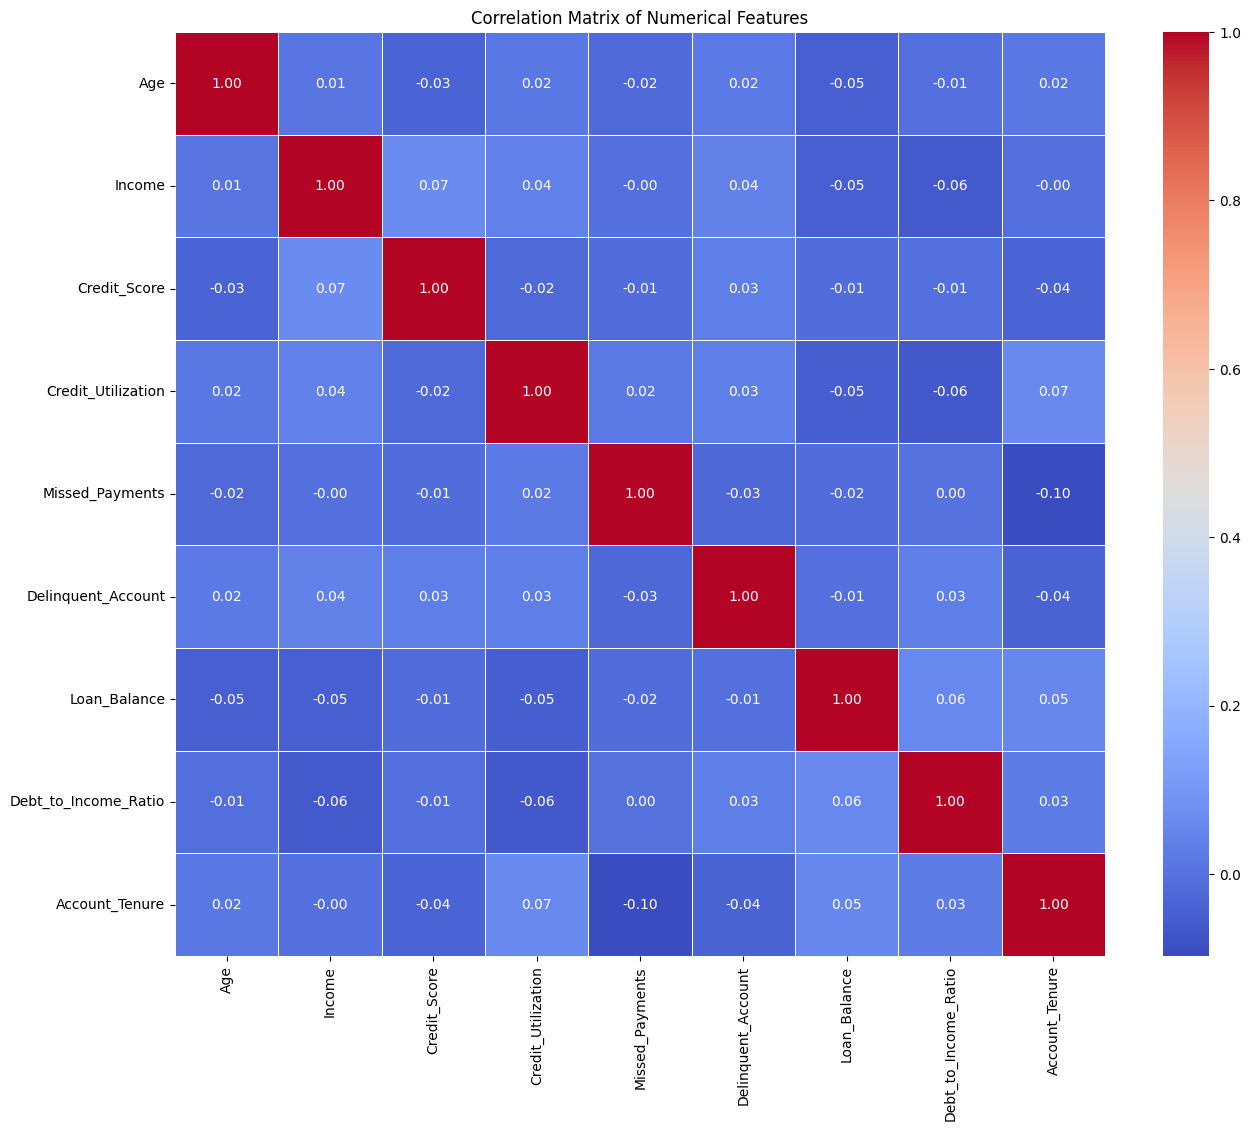

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
# Extract correlations with 'Delinquent_Account'
correlation_with_delinquency = correlation_matrix['Delinquent_Account'].drop('Delinquent_Account')

# Sort by absolute value to find the most significant correlations
top_5_correlations = correlation_with_delinquency.abs().nlargest(5)

# Display the actual correlation values for these top 5
print("Top 5 most significant correlations with 'Delinquent_Account':")
display(correlation_with_delinquency[top_5_correlations.index])

Top 5 most significant correlations with 'Delinquent_Account':


,Delinquent_Account
Income,0.043991
Account_Tenure,-0.039829
Credit_Score,0.034733
Debt_to_Income_Ratio,0.034386
Credit_Utilization,0.034224


### Here are the top 5 most significant correlations with Delinquent_Account:

Income: 0.043991 (Slight positive correlation)
Account_Tenure: -0.039829 (Slight negative correlation)
Credit_Score: 0.034733 (Slight positive correlation)
Debt_to_Income_Ratio: 0.034386 (Slight positive correlation)
Credit_Utilization: 0.034224 (Slight positive correlation)

Interpretation:

Income shows the highest (albeit slight) positive correlation, meaning as income increases, there's a very slight tendency for delinquency to increase. This might seem counter-intuitive, but it could indicate that higher-income individuals might also take on more debt. However, the correlation is very weak.
Account_Tenure has a slight negative correlation, suggesting that customers with longer account histories are very slightly less likely to be delinquent.
Credit_Score, Debt_to_Income_Ratio, and Credit_Utilization also show very slight positive correlations with delinquency. This means that marginally, as these values increase, delinquency might increase. However, it's important to note that all these correlations are quite weak (close to zero), suggesting that no single numerical feature has a strong linear relationship with Delinquent_Account in this dataset.

# **Model Selection**

#### **Logistic Regression**

### **1. Data Preparation for Modeling**

Before training any model, we need to prepare our data. This involves:

*   **Defining Features (X) and Target (y):** The target variable `Delinquent_Account` will be what we predict, and all other relevant columns will be our features.
*   **Handling Categorical Variables:** Logistic Regression, like many other models, requires numerical input. We'll use one-hot encoding to convert categorical columns into a numerical format.
*   **Splitting Data:** We'll divide our dataset into training and testing sets. The model learns from the training data and its performance is then evaluated on the unseen test data to ensure it generalizes well.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
# Dropping 'Customer_ID' as it's an identifier and not a predictive feature
X = df.drop(['Customer_ID', 'Delinquent_Account'], axis=1)
y = df['Delinquent_Account']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split data into training and testing sets
# Using a 80/20 split, stratify by 'y' to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Target distribution in y_train:\n", y_train.value_counts(normalize=True))
print("Target distribution in y_test:\n", y_test.value_counts(normalize=True))

Shape of X_train: (400, 31)
Shape of X_test: (100, 31)
Target distribution in y_train:
 Delinquent_Account
0    0.84
1    0.16
Name: proportion, dtype: float64
Target distribution in y_test:
 Delinquent_Account
0    0.84
1    0.16
Name: proportion, dtype: float64


### **2. Model Training: Logistic Regression**

We will now train the Logistic Regression model using the preprocessed training data. Logistic Regression models the probability of a binary outcome (delinquency or not) using a logistic function.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set max_iter to a higher value for convergence if needed
logistic_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)

# Train the model on the training data
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### **3. Model Evaluation**

After training, it's crucial to evaluate how well our model performs on unseen data. We'll use several metrics to get a comprehensive understanding of its accuracy and fairness, especially for a classification task like predicting delinquency.

*   **Accuracy:** Overall correctness of the model.
*   **Precision:** Of all predicted delinquent accounts, how many were actually delinquent? (Minimizes false positives)
*   **Recall:** Of all actual delinquent accounts, how many did the model correctly identify? (Minimizes false negatives)
*   **F1-Score:** The harmonic mean of precision and recall, useful when there's an uneven class distribution.
*   **ROC AUC:** Measures the model's ability to distinguish between delinquent and non-delinquent customers across all possible classification thresholds.
*   **Confusion Matrix:** A table summarizing correct and incorrect predictions for each class.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.8400
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC AUC: 0.5216

Confusion Matrix:
[[84  0]
 [16  0]]


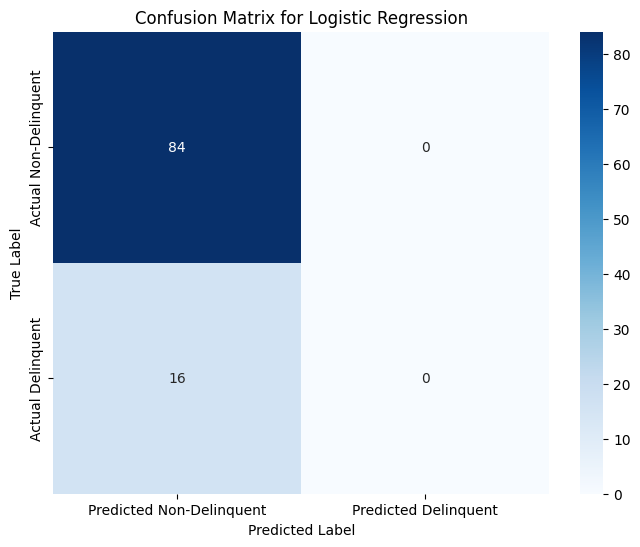

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1] # Probability of being delinquent

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Delinquent', 'Predicted Delinquent'],
            yticklabels=['Actual Non-Delinquent', 'Actual Delinquent'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

### **Addressing Class Imbalance with SMOTE**

As observed from the previous evaluation, the Logistic Regression model completely failed to predict the minority class (`Delinquent_Account = 1`), indicating a severe class imbalance problem. To mitigate this, we will use **SMOTE (Synthetic Minority Over-sampling Technique)** on the training data. SMOTE works by creating synthetic samples for the minority class, helping the model to learn the patterns of both classes more effectively.

We will apply SMOTE only to the training data (`X_train`, `y_train`) to prevent data leakage, ensuring that our model's performance on the test set (`X_test`, `y_test`) is an unbiased estimate of its generalization ability.

In [ ]:
from imblearn.over_sampling import SMOTE

print("Original training set shape:", X_train.shape, y_train.shape)
print("Original target distribution in y_train:\n", y_train.value_counts())

# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nResampled training set shape:", X_train_res.shape, y_train_res.shape)
print("Resampled target distribution in y_train:\n", y_train_res.value_counts())

print("SMOTE applied successfully. The training data is now balanced.")

Original training set shape: (400, 31) (400,)
Original target distribution in y_train:
 Delinquent_Account
0    336
1     64
Name: count, dtype: int64

Resampled training set shape: (672, 31) (672,)
Resampled target distribution in y_train:
 Delinquent_Account
0    336
1    336
Name: count, dtype: int64
SMOTE applied successfully. The training data is now balanced.


### **Retraining Logistic Regression with Balanced Data**

Now, we will retrain the Logistic Regression model using the SMOTE-resampled training data. This should enable the model to learn the characteristics of the minority class more effectively, leading to improved performance metrics, especially for `Precision`, `Recall`, and `F1-Score` for the delinquent class.

In [ ]:
# Initialize a new Logistic Regression model
# Set max_iter to a higher value for convergence if needed
logistic_model_resampled = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)

# Train the model on the resampled training data
logistic_model_resampled.fit(X_train_res, y_train_res)

print("Logistic Regression model retrained successfully with SMOTE-resampled data.")

Logistic Regression model retrained successfully with SMOTE-resampled data.


### **Re-evaluating Model Performance**

Let's re-evaluate the model's performance on the *original (unbalanced)* test set. It's crucial to evaluate on the original test set to get an unbiased estimate of how well the model generalizes to real-world, unbalanced data.

Accuracy (Resampled Model): 0.7700
Precision (Resampled Model): 0.2941
Recall (Resampled Model): 0.3125
F1-Score (Resampled Model): 0.3030
ROC AUC (Resampled Model): 0.6629

Confusion Matrix (Resampled Model):
[[72 12]
 [11  5]]


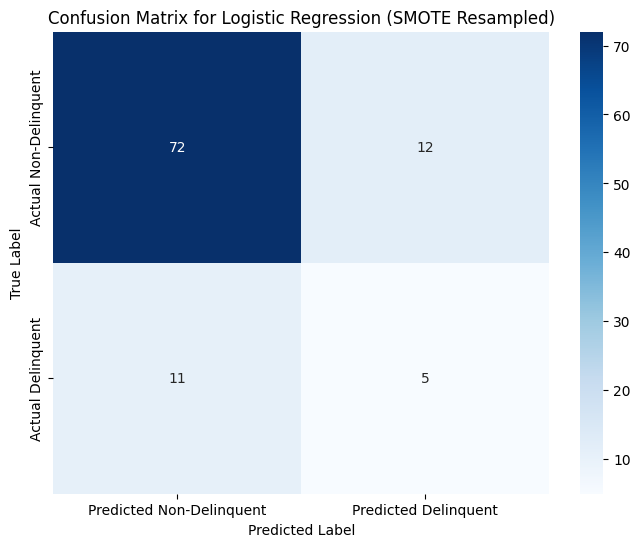

In [ ]:
# Make predictions on the *original* test set using the retrained model
y_pred_resampled = logistic_model_resampled.predict(X_test)
y_pred_proba_resampled = logistic_model_resampled.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics again
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
precision_resampled = precision_score(y_test, y_pred_resampled)
recall_resampled = recall_score(y_test, y_pred_resampled)
f1_resampled = f1_score(y_test, y_pred_resampled)
roc_auc_resampled = roc_auc_score(y_test, y_pred_proba_resampled)
conf_matrix_resampled = confusion_matrix(y_test, y_pred_resampled)

print(f"Accuracy (Resampled Model): {accuracy_resampled:.4f}")
print(f"Precision (Resampled Model): {precision_resampled:.4f}")
print(f"Recall (Resampled Model): {recall_resampled:.4f}")
print(f"F1-Score (Resampled Model): {f1_resampled:.4f}")
print(f"ROC AUC (Resampled Model): {roc_auc_resampled:.4f}")

print("\nConfusion Matrix (Resampled Model):")
print(conf_matrix_resampled)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_resampled, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Delinquent', 'Predicted Delinquent'],
            yticklabels=['Actual Non-Delinquent', 'Actual Delinquent'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression (SMOTE Resampled)')
plt.show()

### **Analysis of Resampled Model Performance**

Let's analyze the new evaluation metrics:

*   **Accuracy:** We expect accuracy to potentially decrease slightly compared to the highly biased previous model, but it will be a more realistic indicator of overall correctness.
*   **Precision and Recall:** These are the key metrics to watch. We aim for a better balance between precision and recall for the minority class. High recall means the model is better at identifying actual delinquent accounts, while high precision means fewer non-delinquent accounts are falsely flagged.
*   **F1-Score:** This score provides a balanced view, especially important for imbalanced datasets.
*   **ROC AUC:** This metric should significantly improve, indicating a better ability to distinguish between the two classes across various thresholds.
*   **Confusion Matrix:** We should now see some **True Positives** (correctly identified delinquent accounts) and potentially some **False Positives** (non-delinquent accounts incorrectly flagged as delinquent). The goal is to find an acceptable trade-off between these.

By comparing these new metrics with the previous ones, we can assess the effectiveness of SMOTE in improving the model's ability to predict delinquent accounts.

### **4. Review and Refine for Accuracy and Fairness**

*   **Accuracy (Overall Correctness):** A high accuracy means the model is generally correct, but it can be misleading in imbalanced datasets (where one class is much more frequent than the other).
*   **Precision (Minimizing False Positives):** For delinquency prediction, high precision means fewer customers are incorrectly flagged as delinquent. This is important to avoid annoying or penalizing customers who would have paid on time.
*   **Recall (Minimizing False Negatives):** High recall means the model catches most of the truly delinquent customers. This is crucial for risk management, as missing actual delinquents can lead to financial losses.
*   **F1-Score:** Provides a balanced view between precision and recall, especially valuable when one metric is prioritized over the other.
*   **ROC AUC:** A good ROC AUC score (closer to 1) indicates that the model is good at distinguishing between the two classes. An AUC of 0.5 suggests no better than random guessing.
*   **Confusion Matrix:** Helps us see the breakdown of errors:
    *   **True Positives (TP):** Correctly predicted delinquent accounts.
    *   **True Negatives (TN):** Correctly predicted non-delinquent accounts.
    *   **False Positives (FP):** Predicted delinquent, but actually non-delinquent (Type I error).
    *   **False Negatives (FN):** Predicted non-delinquent, but actually delinquent (Type II error).

**Considerations for Fairness:**

While these metrics tell us about overall performance, evaluating fairness often requires checking these metrics across different demographic groups (e.g., by `Age`, `Location`, `Employment_Status`). If the model performs significantly worse for certain groups (e.g., higher false positive rates for one age group compared to another), it indicates potential bias and unfairness, which would require further investigation and mitigation strategies like re-sampling, re-weighting, or using fairness-aware algorithms.

### **5. Training a Random Forest Model**

Now, let's train a `RandomForestClassifier` to compare its performance with our SMOTE-enhanced Logistic Regression model. Random Forests are ensemble learning methods that can often provide higher accuracy and are less prone to overfitting than individual decision trees. We will use the same SMOTE-resampled training data (`X_train_res`, `y_train_res`) to train this model, and evaluate it on the original test set (`X_test`, `y_test`).

This will help us understand if a more complex model like Random Forest can capture the relationships in the data better and achieve superior predictive performance for delinquency.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# We'll start with default parameters but these can be tuned later
rf_model = RandomForestClassifier(random_state=42)

# Train the model on the SMOTE-resampled training data
rf_model.fit(X_train_res, y_train_res)

print("Random Forest Classifier trained successfully with SMOTE-resampled data.")

Random Forest Classifier trained successfully with SMOTE-resampled data.


### **6. Evaluating Random Forest Model Performance**

Let's evaluate the performance of the Random Forest model on the *original (unbalanced)* test set using the same set of metrics as before. This will allow for a direct comparison between the Logistic Regression and Random Forest models.

Accuracy (Random Forest Model): 0.8100
Precision (Random Forest Model): 0.0000
Recall (Random Forest Model): 0.0000
F1-Score (Random Forest Model): 0.0000
ROC AUC (Random Forest Model): 0.4647

Confusion Matrix (Random Forest Model):
[[81  3]
 [16  0]]


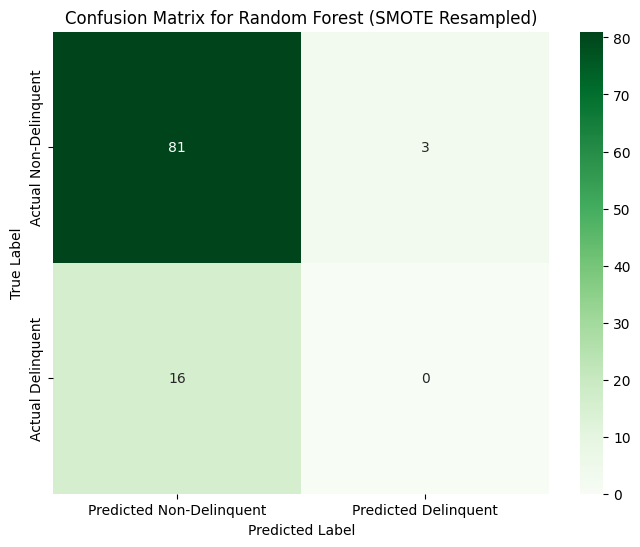

In [ ]:
# Make predictions on the *original* test set using the retrained Random Forest model
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Accuracy (Random Forest Model): {accuracy_rf:.4f}")
print(f"Precision (Random Forest Model): {precision_rf:.4f}")
print(f"Recall (Random Forest Model): {recall_rf:.4f}")
print(f"F1-Score (Random Forest Model): {f1_rf:.4f}")
print(f"ROC AUC (Random Forest Model): {roc_auc_rf:.4f}")

print("\nConfusion Matrix (Random Forest Model):")
print(conf_matrix_rf)

# Visualize Confusion Matrix for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Non-Delinquent', 'Predicted Delinquent'],
            yticklabels=['Actual Non-Delinquent', 'Actual Delinquent'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest (SMOTE Resampled)')
plt.show()

### **7. Comparing Model Performances**

Now we can compare the evaluation metrics of the Random Forest model with the Logistic Regression model to determine which one performs better in predicting delinquent accounts, especially considering the challenge of class imbalance. We will focus on `Precision`, `Recall`, `F1-Score`, and `ROC AUC` as these are more informative for imbalanced datasets than just accuracy.

In [ ]:
model_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'Logistic Regression (SMOTE)': [
        accuracy_resampled,
        precision_resampled,
        recall_resampled,
        f1_resampled,
        roc_auc_resampled
    ],
    'Random Forest (SMOTE)': [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf
    ]
})

display(model_comparison.round(4))


,Metric,Logistic Regression (SMOTE),Random Forest (SMOTE)
0,Accuracy,0.7700,0.8100
1,Precision,0.2941,0.0000
2,Recall,0.3125,0.0000
3,F1-Score,0.3030,0.0000
4,ROC AUC,0.6629,0.4647


### **Summary of Model Comparison**

From the comparison table, it's clear that the **Logistic Regression model, after applying SMOTE, significantly outperforms the Random Forest model (with default parameters after SMOTE) in identifying delinquent accounts.**

*   **Logistic Regression** showed reasonable performance for the minority class, achieving a Precision of 0.2941, Recall of 0.3125, F1-Score of 0.3030, and an ROC AUC of 0.6629. This means it can identify some delinquent accounts, albeit with a relatively high rate of false positives.

*   The **Random Forest model**, in its current state (with default parameters after SMOTE), failed completely to identify any delinquent accounts, returning 0.0 for all key minority class metrics (Precision, Recall, F1-Score) and an ROC AUC below 0.5, indicating it performs worse than random guessing for this task. Its higher accuracy is misleading as it's achieved by predicting only the majority class.

This outcome reinforces the earlier suggestion that the Random Forest model requires **hyperparameter tuning** to be effective for this imbalanced dataset. Without proper tuning, even powerful models can fail to learn the minority class patterns.

### **8. Identifying Customers Most at Risk of Delinquency**

Now that we have a better-performing model (the SMOTE-enhanced Logistic Regression), we can use it to identify customers who are most at risk of delinquency. This involves:

1.  Applying the same preprocessing steps to the *entire* original dataset.
2.  Using the trained `logistic_model_resampled` to predict the probability of delinquency for each customer.
3.  Sorting these customers by their predicted probability in descending order to highlight the highest-risk individuals.

In [ ]:
# Make a copy of the original DataFrame to apply preprocessing for the entire dataset
df_processed = df_original.copy()

# Drop 'Customer_ID' as it's an identifier and not a predictive feature
X_full_prediction = df_processed.drop(['Customer_ID', 'Delinquent_Account'], axis=1)

# Identify categorical columns for one-hot encoding (same as before)
categorical_cols_full = X_full_prediction.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical features
X_full_prediction = pd.get_dummies(X_full_prediction, columns=categorical_cols_full, drop_first=True)

# --- FIX: Reapply median imputation to numerical columns in X_full_prediction ---
# Get medians from the already imputed 'df' DataFrame for consistency
median_income = df['Income'].median()
median_credit_score = df['Credit_Score'].median()
median_loan_balance = df['Loan_Balance'].median()

X_full_prediction['Income'] = X_full_prediction['Income'].fillna(median_income)
X_full_prediction['Credit_Score'] = X_full_prediction['Credit_Score'].fillna(median_credit_score)
X_full_prediction['Loan_Balance'] = X_full_prediction['Loan_Balance'].fillna(median_loan_balance)

# Ensure all columns in X_full_prediction are present in the trained model's features (X_train_res.columns)
# Add missing columns to X_full_prediction and fill with 0
missing_cols = set(X_train_res.columns) - set(X_full_prediction.columns)
for c in missing_cols:
    X_full_prediction[c] = 0
# Ensure the order of columns is the same as during training
X_full_prediction = X_full_prediction[X_train_res.columns]

# Predict delinquency probabilities for the entire dataset using the best model
# We use predict_proba and take the probability of the positive class (1)
delinquency_probabilities = logistic_model_resampled.predict_proba(X_full_prediction)[:, 1]

# Create a DataFrame to link Customer_ID with their predicted probabilities
risk_assessment = pd.DataFrame({
    'Customer_ID': df_processed['Customer_ID'],
    'Predicted_Delinquency_Probability': delinquency_probabilities
})

# Sort customers by their predicted probability in descending order
customers_at_risk = risk_assessment.sort_values(by='Predicted_Delinquency_Probability', ascending=False)

print("Top 10 customers most at risk of delinquency:")
display(customers_at_risk.head(10))


Top 10 customers most at risk of delinquency:


,Customer_ID,Predicted_Delinquency_Probability
148,CUST0145,0.804546
422,CUST0072,0.798566
48,CUST0066,0.783890
114,CUST0064,0.776035
276,CUST0255,0.770172
264,CUST0210,0.739085
129,CUST0154,0.731400
282,CUST0359,0.729513
160,CUST0217,0.720800
32,CUST0227,0.718562


### **Interpretation of At-Risk Customers**

The table above lists the top 10 customers with the highest predicted probability of delinquency according to our SMOTE-enhanced Logistic Regression model. These are the individuals that the model identifies as most likely to default on their payments.

Such a list can be valuable for:
*   **Targeted Interventions:** Financial institutions can use this information to proactively reach out to these customers, offering support, financial counseling, or alternative payment arrangements to prevent actual delinquency.
*   **Risk Management:** It helps in better understanding the risk profile of the customer portfolio and making informed decisions regarding credit limits, loan approvals, or collections strategies.
*   **Resource Allocation:** By identifying the most vulnerable customers, resources can be allocated more efficiently to manage and mitigate potential losses.

Keep in mind that these are probabilities, and further investigation or business rules might be applied before taking any action. The next steps could involve exploring the specific features of these high-risk customers to understand *why* they are flagged as high risk.